In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


BASE        = Path("/~/HMM-PROFILES-FOR-CA-ENZYMES")
REBASE      = BASE / "OUTPUT"
RESULTS = REBASE / "results"
HMM_LIB = REBASE / "hmmer_lib"  

# CA family names 
CA_FAMILIES = ["alpha", "beta", "gamma", "delta", "epsilon", "zeta", "eta", "theta", "iota"]

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print(f"Base path: {BASE}")
print(f"Results path: {RESULTS}")
print(f"HMM library: {HMM_LIB}")

In [ ]:

def parse_all_hmms_from_file(hmm_file):
    AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
    all_hmms = {}
    
    with open(hmm_file, 'r') as f:
        current_emissions = []
        current_metadata = {}
        in_hmm = False
        aa_order = None
        
        for line in f:
            line_stripped = line.strip()
            
            #new HMM
            if line_stripped.startswith("HMMER3"):
                current_emissions = []
                current_metadata = {}
                in_hmm = False
                aa_order = None
                continue
            
            # parse metadata
            if line_stripped.startswith("NAME"):
                parts = line_stripped.split()
                current_metadata['name'] = parts[1] if len(parts) > 1 else ""
            elif line_stripped.startswith("LENG"):
                current_metadata['length'] = int(line_stripped.split()[1])
            elif line_stripped.startswith("ALPH"):
                current_metadata['alphabet'] = line_stripped.split()[1]
            
            # amino acid order from HMM header line
            elif line_stripped.startswith("HMM ") and "A" in line_stripped:
                parts = line_stripped.split()
                if len(parts) > 1:
                    aa_order = parts[1:]  # Skip 'HMM'
                in_hmm = True
                continue
            
            # skip the transition probability header line
            elif in_hmm and line_stripped.startswith("m->m"):
                continue
            
            # parse match state emissions
            if in_hmm and line_stripped and not line_stripped.startswith("//"):
                parts = line_stripped.split()
                
                # match state lines: position number followed by 20 emission values
                if len(parts) >= 21 and parts[0].isdigit():
                    log_probs = []
                    for p in parts[1:21]:
                        if p == '*':
                            log_probs.append(-np.inf)
                        else:
                            log_probs.append(-float(p))
                    
                    probs = np.exp(log_probs)
                    probs = probs / probs.sum()
                    current_emissions.append(probs)
            
            # end of current HMM - save it
            if line_stripped.startswith("//"):
                if current_emissions and current_metadata.get('name'):
                    if aa_order is None or len(aa_order) != 20:
                        aa_order = AMINO_ACIDS
                    
                    df = pd.DataFrame(current_emissions, columns=aa_order)
                    df.index = range(1, len(df) + 1)
                    df.index.name = 'position'
                    
                    name = current_metadata['name']
                    all_hmms[name] = (df, current_metadata)
                    print(f"  Parsed: {name} ({len(df)} positions)")
                
                # reset for next HMM
                current_emissions = []
                current_metadata = {}
                in_hmm = False
                aa_order = None
    
    return all_hmms

# parse the concat HMM file
ALL_HMM = HMM_LIB / "all_classes.hmm"  # adj if diff filename

if ALL_HMM.exists():
    print(f"Parsing HMMs from: {ALL_HMM}")
    all_hmms = parse_all_hmms_from_file(ALL_HMM)
    print(f"\nFound {len(all_hmms)} HMMs: {list(all_hmms.keys())}")
else:
    print(f"File not found: {ALL_HMM}")
    all_hmms = {}

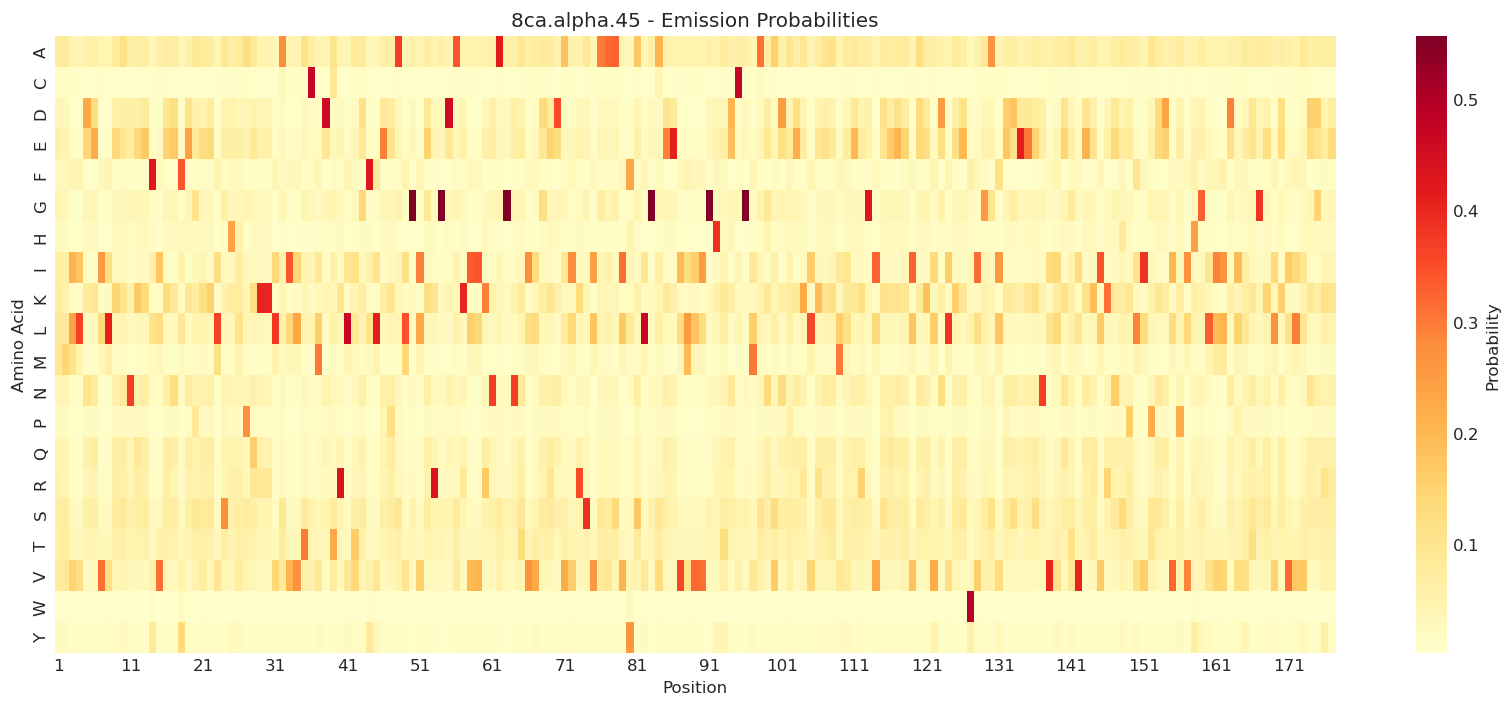

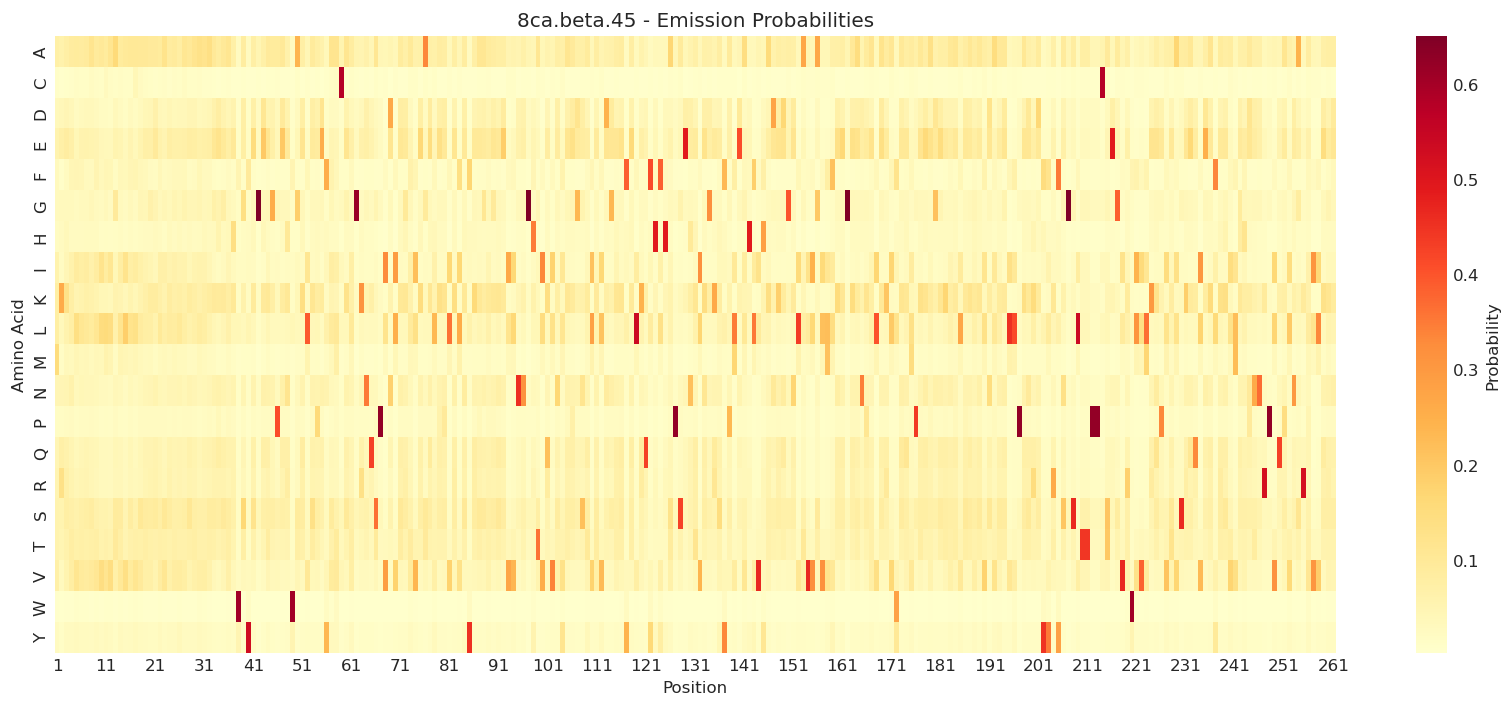

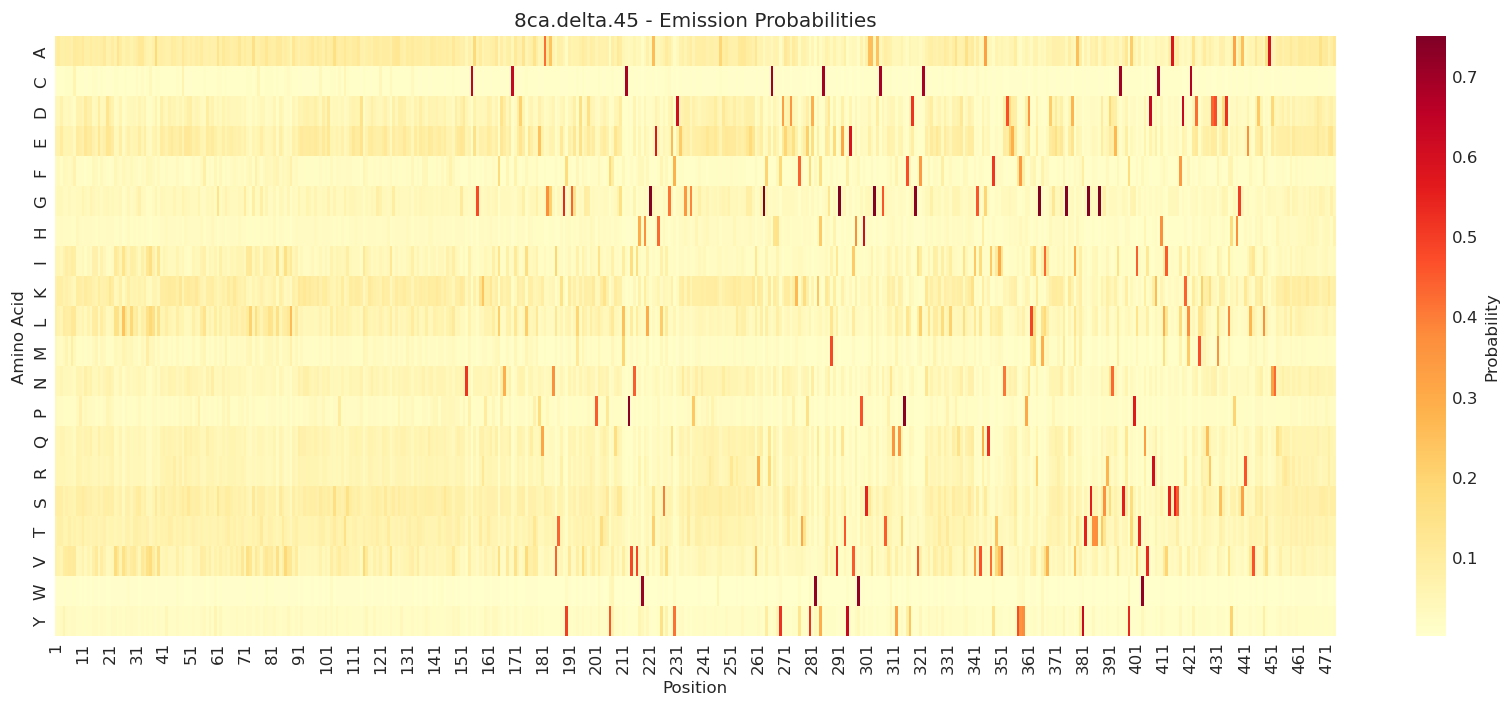

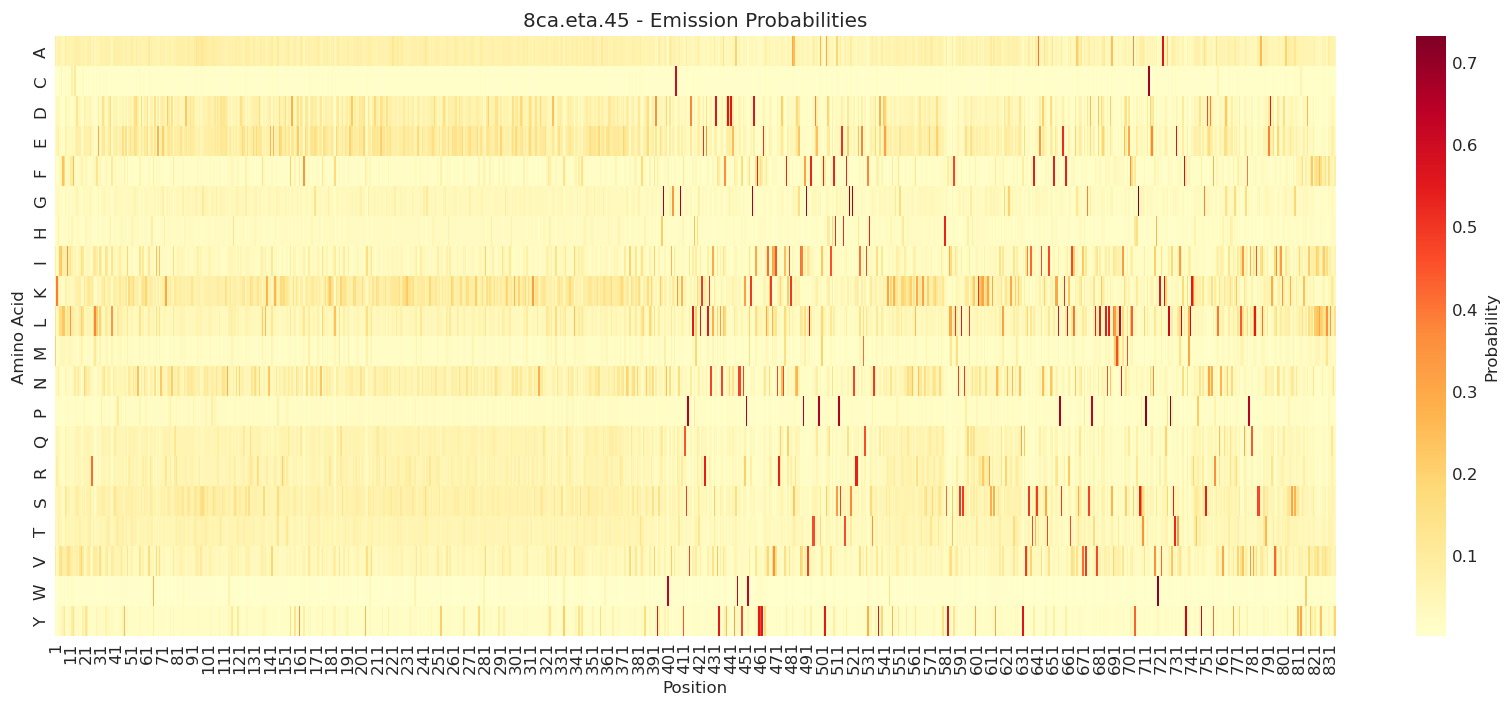

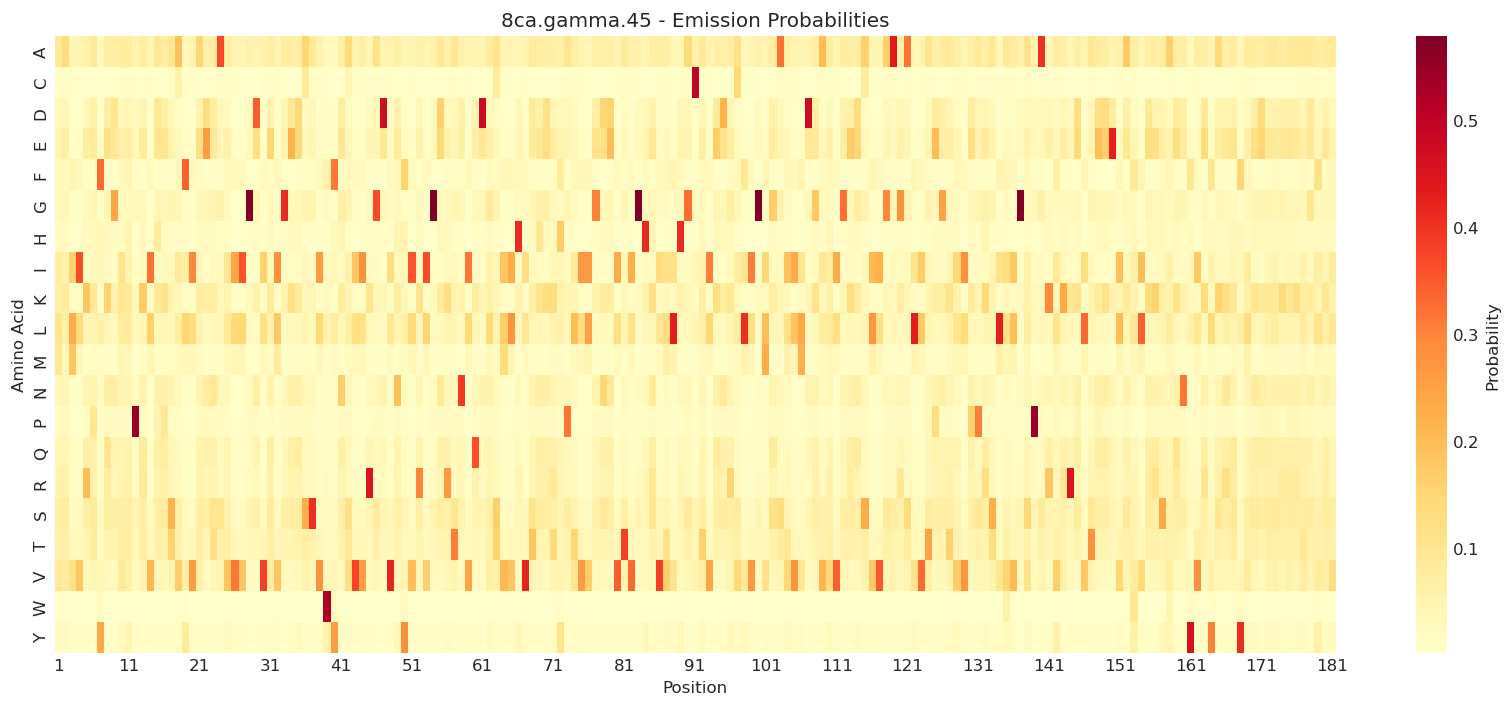

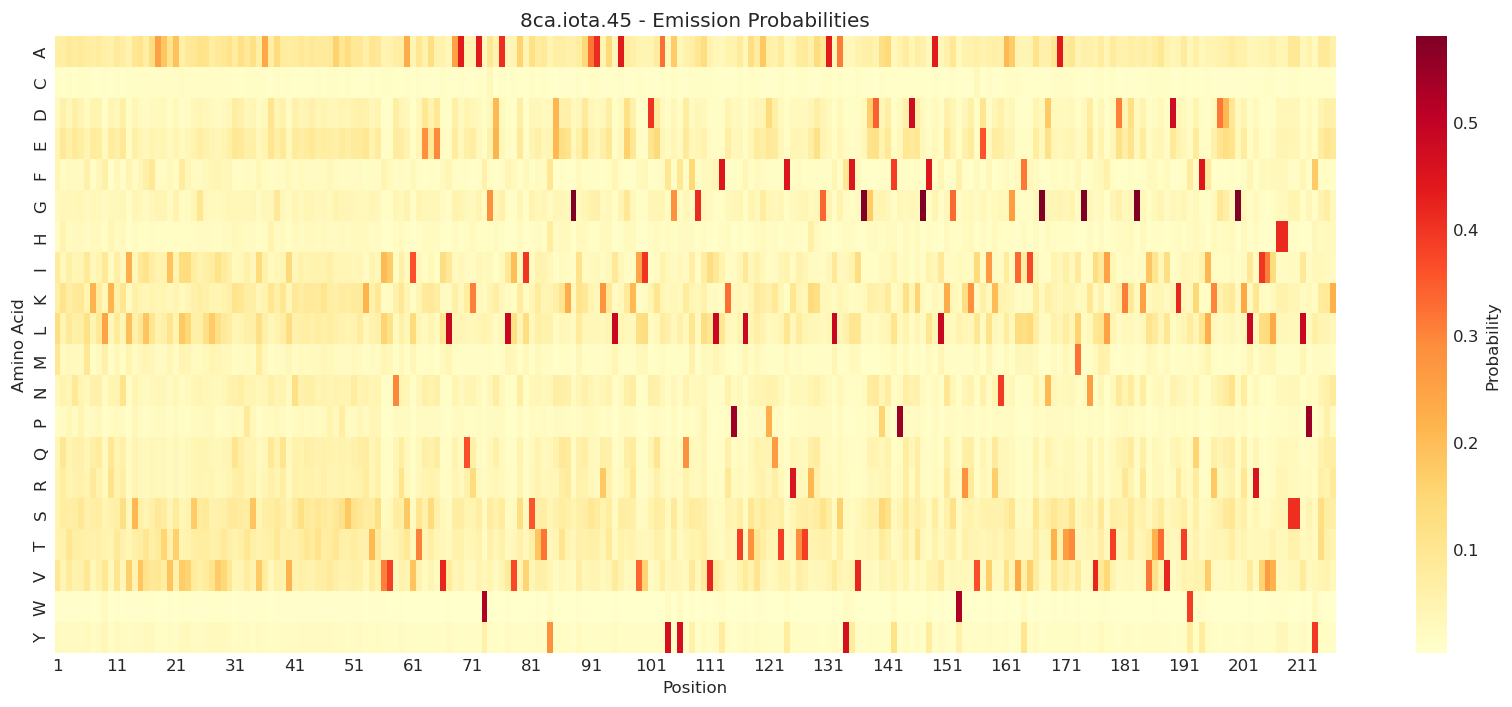

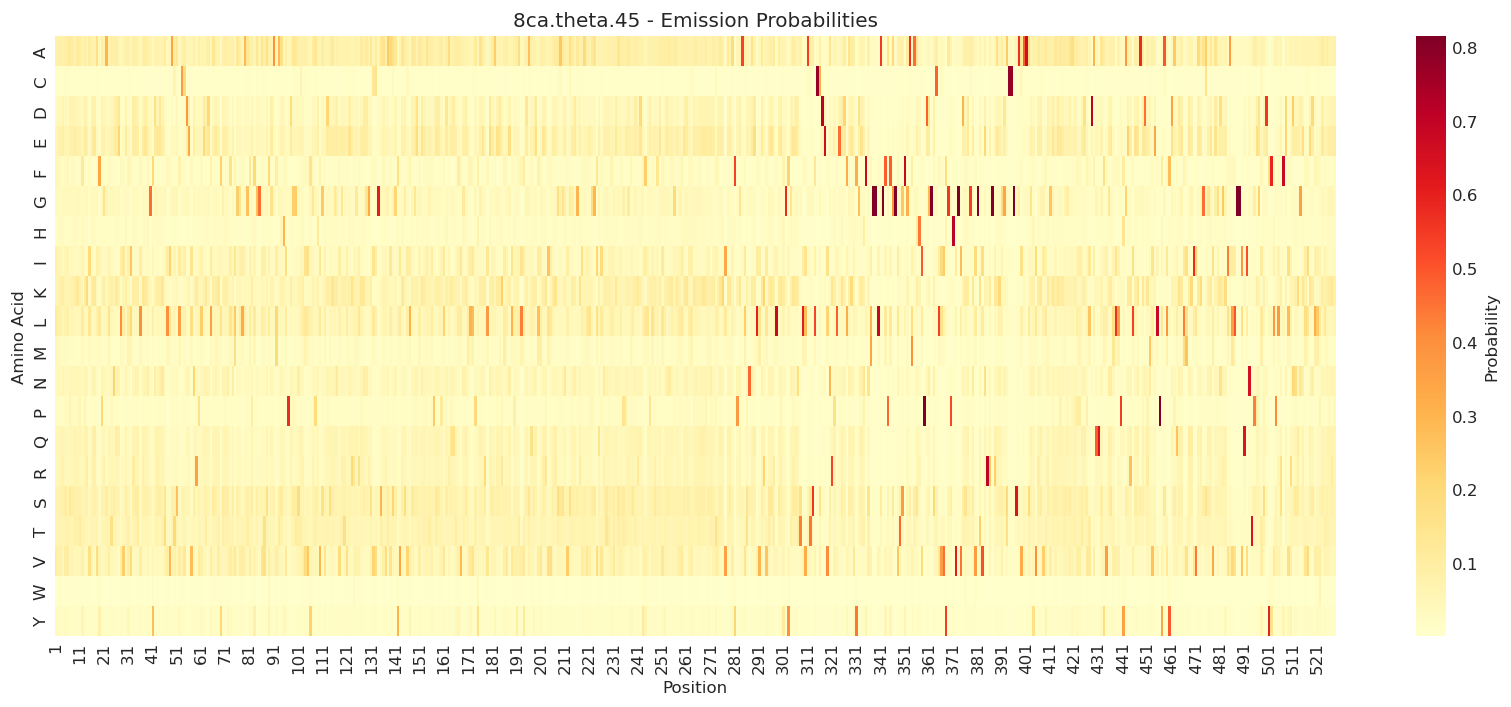

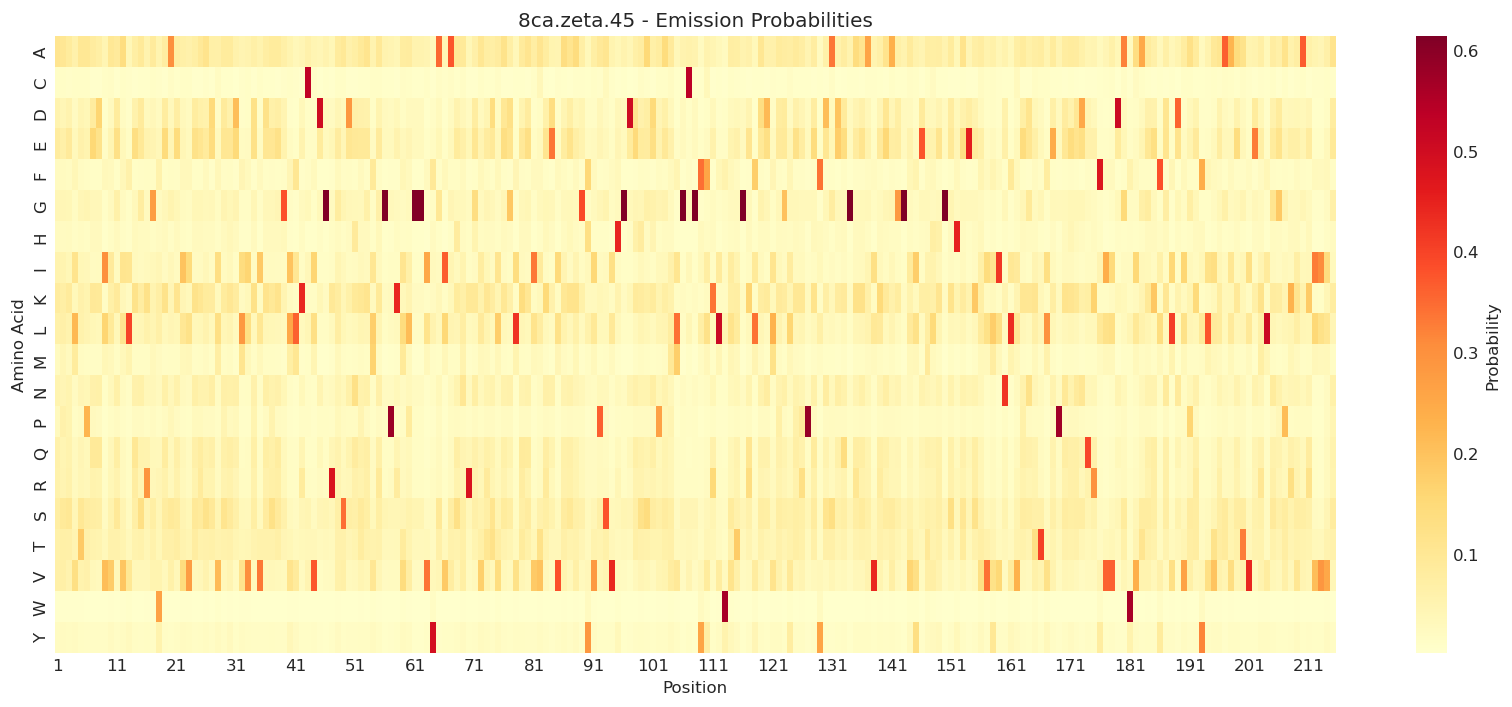

In [14]:
def plot_hmm_heatmap(emissions_df, title, figsize=(14, 6)):
    """Simple, clean heatmap for HMM emission probabilities."""
    fig, ax = plt.subplots(figsize=figsize)
    
    # n positions 
    data = emissions_df.iloc[:1000].T
    
    sns.heatmap(data, cmap='YlOrRd', ax=ax,
                xticklabels=10, yticklabels=True,
                cbar_kws={'label': 'Probability'})
    
    ax.set_xlabel('Position')
    ax.set_ylabel('Amino Acid')
    ax.set_title(title)
    plt.tight_layout()
    return fig

# gen one heatmap per family
for hmm_name, (emissions_df, meta) in all_hmms.items():
    fig = plot_hmm_heatmap(emissions_df, f"{hmm_name} - Emission Probabilities")
    plt.show()
    plt.close()

In [4]:

LABELS_CSV = RESULTS / "uniprot_first_150000_labels_with_confidence.csv"

if not LABELS_CSV.exists():
    candidates = list(RESULTS.glob("*labels*.csv")) + list(RESULTS.glob("*predictions*.csv"))
    if candidates:
        LABELS_CSV = candidates[0]
        print(f"Using: {LABELS_CSV}")

if LABELS_CSV.exists():
    df = pd.read_csv(LABELS_CSV)
    print(f"Loaded {len(df):,} sequences")
    print(f"Columns: {list(df.columns)}")
    print(f"\nClass distribution:")
    print(df['pred_class'].value_counts())
    
    display(df.head())
else:
    print(f"Results file not found: {LABELS_CSV}")
    print("Please set LABELS_CSV to your classification results file.")
    df = None

Loaded 148,727 sequences
Columns: ['seq_id', 'pred_model', 'bit_score', 'evalue', 'pred_class', 'confidence']

Class distribution:
pred_class
alpha     56772
gamma     43672
beta      39995
NO_HIT     7549
delta       605
eta         114
theta        13
zeta          5
iota          2
Name: count, dtype: int64


,seq_id,pred_model,bit_score,evalue,pred_class,confidence
0,tr|A0A6A4STS7|A0A6A4STS7_SCOMX,8ca.beta.45,99.6,8.900000e-32,beta,31.050610
1,tr|A0A834BR83|A0A834BR83_ORYME,8ca.beta.45,99.1,1.200000e-31,beta,30.920819
2,tr|A0A8C8XNP7|A0A8C8XNP7_PANLE,NaN,NaN,NaN,NO_HIT,NaN
3,tr|A0A9N8V4Z2|A0A9N8V4Z2_9GLOM,8ca.alpha.45,22.2,3.500000e-08,alpha,7.455932
4,tr|A0AAD6AS60|A0AAD6AS60_9TELE,8ca.beta.45,101.0,3.400000e-32,beta,31.468521


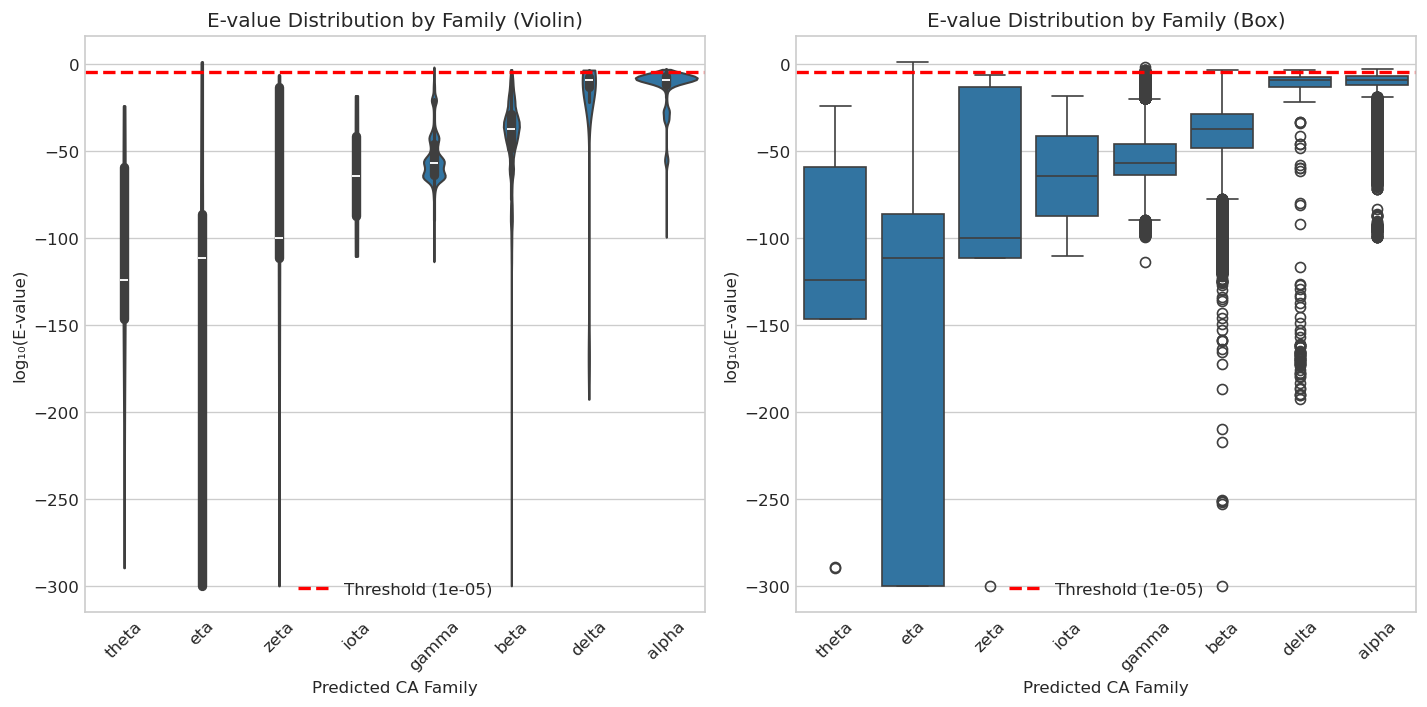

In [5]:

# Box/violin plot of E-value distributions for each predicted class.
# df: DataFrame with E-values and class predictions
# evalue_col: Column name for E-values
# class_col: Column name for predicted class
# threshold: E-value threshold to highlight

def plot_evalue_distributions(df, evalue_col='evalue', class_col='pred_class', threshold=1e-5, figsize=(12, 6)):
    # Filter out NO_HIT and missing values
    plot_df = df[df[class_col] != 'NO_HIT'].copy()
    plot_df = plot_df[plot_df[evalue_col].notna()]
    
    if len(plot_df) == 0:
        print("No data to plot after filtering.")
        return None, None
    
    # log-transform e-vals
    plot_df['log_evalue'] = np.log10(plot_df[evalue_col].clip(lower=1e-300))
    
    # Order classes by median E-val
    class_order = (plot_df.groupby(class_col)['log_evalue']
                   .median()
                   .sort_values()
                   .index.tolist())
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # violin plot
    ax1 = axes[0]
    sns.violinplot(data=plot_df, x=class_col, y='log_evalue', 
                   order=class_order, ax=ax1, inner='box', cut=0)
    ax1.axhline(y=np.log10(threshold), color='red', linestyle='--', 
                label=f'Threshold ({threshold:.0e})', linewidth=2)
    ax1.set_xlabel('Predicted CA Family')
    ax1.set_ylabel('log₁₀(E-value)')
    ax1.set_title('E-value Distribution by Family (Violin)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend()
    
    # box plot
    ax2 = axes[1]
    sns.boxplot(data=plot_df, x=class_col, y='log_evalue',
                order=class_order, ax=ax2)
    ax2.axhline(y=np.log10(threshold), color='red', linestyle='--',
                label=f'Threshold ({threshold:.0e})', linewidth=2)
    ax2.set_xlabel('Predicted CA Family')
    ax2.set_ylabel('log₁₀(E-value)')
    ax2.set_title('E-value Distribution by Family (Box)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend()
    
    plt.tight_layout()
    return fig, axes

if df is not None:
    fig, axes = plot_evalue_distributions(df, threshold=1e-5)
    plt.show()

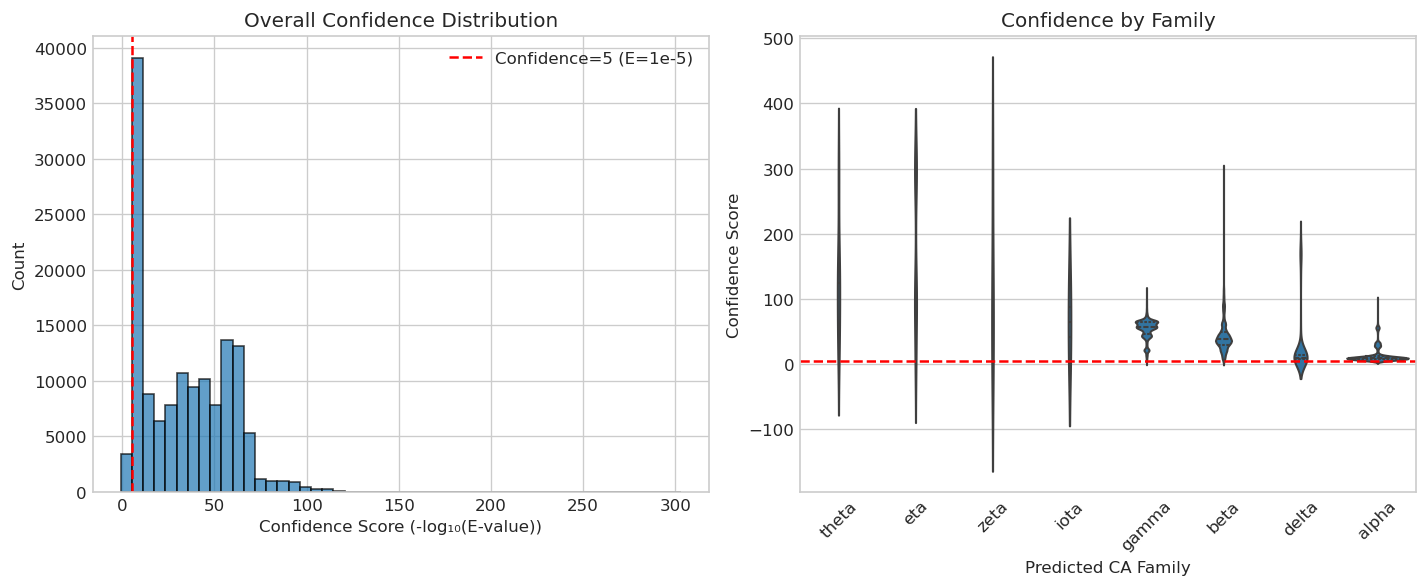

In [7]:
# Confidence scroe distro

def plot_confidence_distribution(df, conf_col='confidence', class_col='pred_class',
                                 figsize=(12, 5)):
    """
    Plot distribution of confidence scores (-log10(E-value)) per class.
    """
    plot_df = df[df[class_col] != 'NO_HIT'].copy()
    plot_df = plot_df[plot_df[conf_col].notna()]
    
    if len(plot_df) == 0:
        print("No data to plot.")
        return None, None
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # histo confidence scores
    ax1 = axes[0]
    ax1.hist(plot_df[conf_col], bins=50, edgecolor='black', alpha=0.7)
    ax1.axvline(x=5, color='red', linestyle='--', label='Confidence=5 (E=1e-5)')
    ax1.set_xlabel('Confidence Score (-log₁₀(E-value))')
    ax1.set_ylabel('Count')
    ax1.set_title('Overall Confidence Distribution')
    ax1.legend()
    
    # per-class violin plot
    ax2 = axes[1]
    class_order = (plot_df.groupby(class_col)[conf_col]
                   .median()
                   .sort_values(ascending=False)
                   .index.tolist())
    sns.violinplot(data=plot_df, x=class_col, y=conf_col,
                   order=class_order, ax=ax2, inner='quartile')
    ax2.axhline(y=5, color='red', linestyle='--', label='E=1e-5')
    ax2.set_xlabel('Predicted CA Family')
    ax2.set_ylabel('Confidence Score')
    ax2.set_title('Confidence by Family')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    return fig, axes

if df is not None and 'confidence' in df.columns:
    fig, axes = plot_confidence_distribution(df)
    plt.show()

In [8]:
#e-value sum stats

def compute_evalue_stats(df, evalue_col='evalue', class_col='pred_class'):
    """
    Compute summary statistics for E-values by class.
    """
    plot_df = df[df[class_col] != 'NO_HIT'].copy()
    plot_df = plot_df[plot_df[evalue_col].notna()]
    
    stats = plot_df.groupby(class_col)[evalue_col].agg([
        ('count', 'count'),
        ('median', 'median'),
        ('mean', 'mean'),
        ('min', 'min'),
        ('max', 'max'),
        ('std', 'std')
    ])
    
    # % below threshold
    for thresh in [1e-5, 1e-10, 1e-20]:
        pct = plot_df.groupby(class_col)[evalue_col].apply(
            lambda x: (x < thresh).mean() * 100
        )
        stats[f'% < {thresh:.0e}'] = pct
    
    return stats.round(4)

if df is not None:
    stats = compute_evalue_stats(df)
    print("E-value Statistics by Predicted Class:")
    display(stats)

E-value Statistics by Predicted Class:


,count,median,mean,min,max,std,% < 1e-05,% < 1e-10,% < 1e-20
pred_class,,,,,,,,,
alpha,56772,0.0,0.0000,0.0,0.0006,0.0000,95.4027,39.3469,17.3589
beta,39995,0.0,0.0000,0.0,0.0004,0.0000,99.7300,97.2447,88.8486
delta,605,0.0,0.0000,0.0,0.0002,0.0000,96.0331,44.4628,14.3802
eta,114,0.0,0.3351,0.0,8.0000,1.5309,92.9825,87.7193,85.9649
gamma,43672,0.0,0.0000,0.0,0.0130,0.0001,99.9336,99.3886,95.9608
iota,2,0.0,0.0000,0.0,0.0000,0.0000,100.0000,100.0000,50.0000
theta,13,0.0,0.0000,0.0,0.0000,0.0000,100.0000,100.0000,100.0000
zeta,5,0.0,0.0000,0.0,0.0000,0.0000,100.0000,80.0000,60.0000


In [9]:
!pip install scikit-learn


Hits retained at key thresholds:
  E <= 1e-03: 141,170 hits (100.0%)
  E <= 1e-05: 138,485 hits (98.1%)
  E <= 1e-10: 105,179 hits (74.5%)
  E <= 1e-20: 87,536 hits (62.0%)
  E <= 1e-50: 42,867 hits (30.4%)


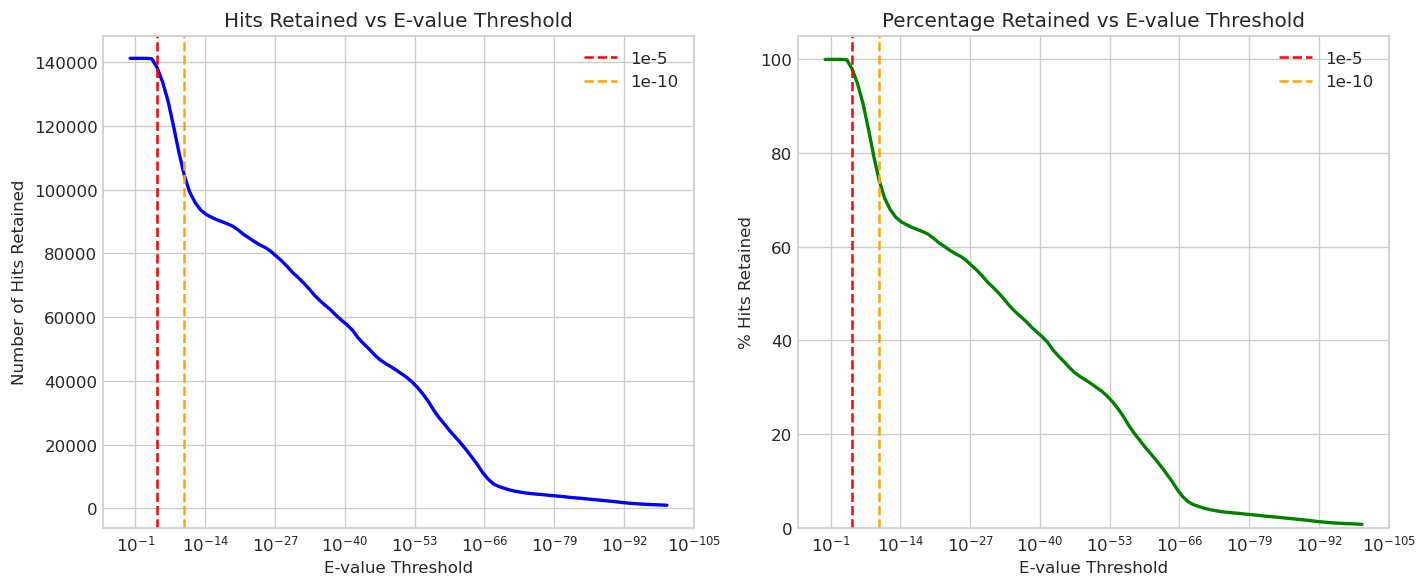

In [10]:
# e-value threshold senstiv analysis
#num hits at each threshold
# precision/recall trade-off
def plot_threshold_analysis(df, evalue_col='evalue', class_col='pred_class', true_col=None, figsize=(12, 5)):
    thresholds = np.logspace(-100, 0, 100)
    
    hits_df = df[df[class_col] != 'NO_HIT'].copy()
    hits_df = hits_df[hits_df[evalue_col].notna()]
    
    n_hits = []
    pct_retained = []
    
    for thresh in thresholds:
        passing = (hits_df[evalue_col] <= thresh).sum()
        n_hits.append(passing)
        pct_retained.append(100 * passing / len(hits_df) if len(hits_df) > 0 else 0)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # num hits vs threshold
    ax1 = axes[0]
    ax1.semilogx(thresholds, n_hits, 'b-', linewidth=2)
    ax1.axvline(x=1e-5, color='red', linestyle='--', label='1e-5')
    ax1.axvline(x=1e-10, color='orange', linestyle='--', label='1e-10')
    ax1.set_xlabel('E-value Threshold')
    ax1.set_ylabel('Number of Hits Retained')
    ax1.set_title('Hits Retained vs E-value Threshold')
    ax1.legend()
    ax1.invert_xaxis()  #lower e-values on right
    
    # % retained vs threshold
    ax2 = axes[1]
    ax2.semilogx(thresholds, pct_retained, 'g-', linewidth=2)
    ax2.axvline(x=1e-5, color='red', linestyle='--', label='1e-5')
    ax2.axvline(x=1e-10, color='orange', linestyle='--', label='1e-10')
    ax2.set_xlabel('E-value Threshold')
    ax2.set_ylabel('% Hits Retained')
    ax2.set_title('Percentage Retained vs E-value Threshold')
    ax2.legend()
    ax2.invert_xaxis()
    ax2.set_ylim([0, 105])
    
    plt.tight_layout()
    
    # print thresholds
    print("\nHits retained at key thresholds:")
    for t in [1e-3, 1e-5, 1e-10, 1e-20, 1e-50]:
        n = (hits_df[evalue_col] <= t).sum()
        pct = 100 * n / len(hits_df) if len(hits_df) > 0 else 0
        print(f"  E <= {t:.0e}: {n:,} hits ({pct:.1f}%)")
    
    return fig, axes

if df is not None:
    fig, axes = plot_threshold_analysis(df)
    plt.show()

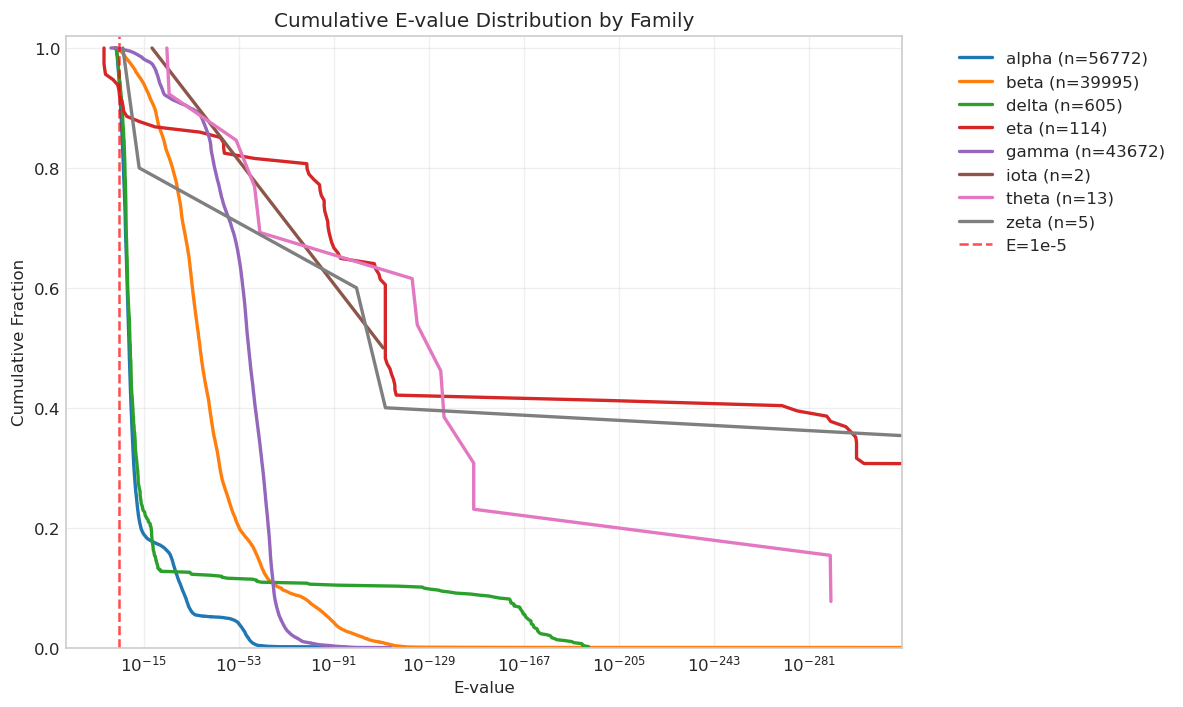

In [11]:
# e-value cum distro plot

# cumulative distribution function of e-vals for each fam
# what fraction of hits are below each e-value threshold
def plot_evalue_cdf(df, evalue_col='evalue', class_col='pred_class', figsize=(10, 6)):
    plot_df = df[df[class_col] != 'NO_HIT'].copy()
    plot_df = plot_df[plot_df[evalue_col].notna()]
    
    families = sorted(plot_df[class_col].unique())
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for family in families:
        subset = plot_df[plot_df[class_col] == family][evalue_col].sort_values()
        cdf = np.arange(1, len(subset) + 1) / len(subset)
        ax.semilogx(subset, cdf, label=f'{family} (n={len(subset)})', linewidth=2)
    
    ax.axvline(x=1e-5, color='red', linestyle='--', alpha=0.7, label='E=1e-5')
    ax.set_xlabel('E-value')
    ax.set_ylabel('Cumulative Fraction')
    ax.set_title('Cumulative E-value Distribution by Family')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim([0, 1.02])
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

if df is not None:
    fig, ax = plot_evalue_cdf(df)
    plt.show()